In [1]:
"""
v2_routing.py
-------------
A LangGraph pipeline that reads a free-format MT599 SWIFT settlement message
(which may contain one or more distinct instructions -- cancellations,
creations, amendments -- mixed together in plain text) and produces ONE
structured JSON output: a list of instructions, each tagged with its type
and annotated with a note if a required field is missing.

This file is self-contained: schema, LLM setup, prompt, graph nodes, graph
build, visualization, and a test invocation. It does not depend on any
other file.

Pipeline, in plain English:

    1. EXTRACT   -- one LLM call reads the whole message and returns EVERY
                    instruction found in it, as structured JSON matching a
                    fixed Pydantic schema (never free-form text).

    2. ROUTE     -- each extracted instruction is routed to a handler based
                    on its `type` (cancel / create / amend / unidentified),
                    using LangGraph's conditional edges.

    3. VALIDATE  -- each type-specific handler checks, in plain Python (no
                    LLM call), whether the fields required for THAT type are
                    present. If something required is missing, a note is
                    appended to the instruction's `remarks` field.

    4. LOOP      -- steps 2-3 repeat once per instruction, using an index
                    counter in the graph state, until every instruction in
                    the message has been routed and validated.

    5. FINALIZE  -- all processed instructions are assembled into a single
                    JSON object: {"instructions": [...]}. This is always the
                    shape returned, whether the message had one instruction,
                    many, or none that could be identified.
"""

import os
import json
from enum import Enum
from typing import Optional, List, TypedDict

from pydantic import BaseModel, Field, ValidationError
from langchain_together import ChatTogether
from langgraph.graph import StateGraph


# ---------------------------------------------------------------------------
# 1. STRUCTURED OUTPUT SCHEMA
#    This is the contract between "whatever the LLM says" and "what our
#    downstream settlement system receives". Pydantic enforces this shape;
#    LangChain uses it to instruct/parse the LLM's structured response.
# ---------------------------------------------------------------------------

class InstructionType(str, Enum):
    """
    The ONE field the graph branches on, so it's constrained to a fixed set
    of values instead of free text. If the LLM could write "Cancellation"
    or "CANCEL" instead of "cancel", the router's string-matching logic
    below would silently break -- forcing an enum here makes that
    impossible.
    """
    cancel = "cancel"
    create = "create"
    amend = "amend"
    unidentified = "unidentified"  # used when no operation could be found


class Instruction(BaseModel):
    """
    One settlement instruction extracted from the message.

    Design decision: every field except `type` is a plain Optional[str].
    We deliberately do NOT try to cast qty to int or settlementDate to a
    date object here. Reasons:
      1. MT599 is free text -- dates/numbers can appear in inconsistent
         formats, and asking a small LLM to also normalize formats increases
         the chance of it silently getting the normalization wrong.
      2. The receiving settlement system already owns format validation
         against its own static/reference data -- duplicating that logic
         here would be redundant and a maintenance burden.
      3. Keeping types uniform (all str) keeps the Pydantic model, and the
         prompt asking the LLM to fill it, simple -- which matters when the
         LLM is a small instruct model, not a frontier reasoning model.
    """
    type: InstructionType = Field(
        description="The operation identified from the message text."
    )
    clientRef: Optional[str] = Field(
        default=None, description="Client reference for this instruction."
    )
    scRef: Optional[str] = Field(
        default=None, description="SC (settlement/system) reference, if present."
    )
    isin: Optional[str] = Field(
        default=None, description="ISIN of the security, if present."
    )
    qty: Optional[str] = Field(
        default=None, description="Quantity, captured exactly as written."
    )
    settlementDate: Optional[str] = Field(
        default=None, description="Settlement date, captured exactly as written."
    )
    sfkAccount: Optional[str] = Field(
        default=None, description="SFK account number, if present."
    )
    pset: Optional[str] = Field(
        default=None, description="Place of settlement, if present."
    )
    party: Optional[str] = Field(
        default=None, description="Party details, if present."
    )
    cpty: Optional[str] = Field(
        default=None, description="Counterparty details, if present."
    )
    remarks: Optional[str] = Field(
        default=None,
        description=(
            "Free-text notes explaining any problem with this instruction. "
            "Two situations populate this field: (a) the extraction node "
            "sets it when type is 'unidentified', explaining why nothing "
            "could be matched; (b) a type-specific handler node sets it "
            "when a required field for that type is missing, e.g. "
            "'Missing required fields: isin, qty'. Both are the same kind "
            "of thing -- a note explaining an issue with this instruction "
            "-- so one field covers both rather than adding a separate flag "
            "for each situation."
        ),
    )


class ExtractionResult(BaseModel):
    """
    Top-level shape returned by this pipeline.

    Design decision: ALWAYS a list, even for a single instruction, and
    ALWAYS non-empty (minimum one entry -- an 'unidentified' placeholder if
    nothing else could be found). This means downstream consumers never
    need to handle "no instructions" as a separate shape from "one
    instruction" from "many instructions" -- one contract, always.
    """
    instructions: List[Instruction] = Field(
        description=(
            "One or more instructions found in the message. If nothing "
            "could be identified, return exactly one instruction with "
            "type='unidentified' and an explanation in remarks."
        )
    )



C:\Users\Pandiyan\anaconda3\envs\langchain\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dotenv import load_dotenv
load_dotenv(".env")
# ---------------------------------------------------------------------------
# 2. LLM SETUP (Together AI via LangChain)
# ---------------------------------------------------------------------------

# Model choice rationale:
#   - Qwen2.5-7B-Instruct-Turbo is confirmed (via LangChain's own docs) to
#     work with ChatTogether's with_structured_output().
#   - It's small/cheap/fast -- good for learning the LangGraph plumbing.
#   - Swap to "Qwen/Qwen2.5-72B-Instruct-Turbo" (one string change) once you
#     want to stress-test with messier / longer MT599 text.
TOGETHER_MODEL = "Qwen/Qwen2.5-7B-Instruct-Turbo"

llm = ChatTogether(
    model=TOGETHER_MODEL,
    temperature=0,  # deterministic extraction -- we want repeatable JSON, not creative text
    together_api_key=os.getenv("TOGETHER_API_KEY"),
)

# method="json_schema" asks the model to emit JSON conforming to our Pydantic
# schema; LangChain sends the schema to Together, which compiles it into a
# constrained-decoding "grammar" and parses the validated response back into
# an ExtractionResult object. This is our PREFERRED mode when it works.
structured_llm_json_schema = llm.with_structured_output(ExtractionResult, method="json_schema")

# FALLBACK: Together AI's grammar compiler can intermittently reject certain
# schema shapes with "Input validation error: grammar is not valid: failed
# to compile grammar" -- a provider-side limitation. Critically, this is NOT
# fixed by switching to method="function_calling", because Together AI
# implements function/tool calling using the SAME grammar-constrained
# decoding engine under the hood -- so a schema that breaks json_schema mode
# breaks function_calling mode too, for the same underlying reason.
#
# The only way to route around a provider-side grammar-compiler bug is to
# stop asking Together to constrain the model's output at all. So the
# fallback here does NOT use with_structured_output() or send our schema to
# Together in any form -- it just prompts the raw `llm` for plain text,
# then WE parse and validate that text ourselves with json.loads() and
# Pydantic. Fewer moving parts than any provider feature, and nothing left
# for their grammar compiler to reject.


def _manual_json_extract(prompt: str) -> ExtractionResult:
    """
    Ask the model for JSON via plain prompting (no schema sent to the
    provider), then parse and validate the response ourselves.
    Raises json.JSONDecodeError or pydantic.ValidationError on failure --
    both are caught by the retry loop in extract_instructions().
    """
    manual_prompt = (
        prompt
        + "\n\nRespond with ONLY a single valid JSON object -- no markdown "
        "code fences, no explanation, no text before or after the JSON. "
        'The JSON must have this exact top-level shape: {"instructions": [...]}, '
        "where each item in the list has the fields described above."
    )
    raw_text = llm.invoke(manual_prompt).content.strip()

    # Models sometimes wrap JSON in ```json ... ``` fences even when told
    # not to -- strip those defensively before parsing.
    if raw_text.startswith("```"):
        raw_text = raw_text.strip("`")
        if raw_text.lower().startswith("json"):
            raw_text = raw_text[4:]
        raw_text = raw_text.strip()

    data = json.loads(raw_text)          # may raise json.JSONDecodeError
    return ExtractionResult.model_validate(data)  # may raise pydantic.ValidationError


In [3]:
# ---------------------------------------------------------------------------
# 3. PROMPT
# ---------------------------------------------------------------------------

EXTRACTION_PROMPT = """You are parsing a free-format MT599 SWIFT message used in trade settlement.

The message may contain ONE OR MORE distinct instructions (cancellation, creation, amendment),
mixed together in free text, in any order.

For EACH instruction you find, extract:
- type: cancel, create, amend, or unidentified
- clientRef, scRef, isin, qty, settlementDate, sfkAccount, pset, party, cpty
- remarks: only used to explain when type is "unidentified"

Rules:
1. Capture every field exactly as written in the message. Do NOT reformat dates,
   numbers, or reference codes.
2. If a field is not mentioned for an instruction, leave it null. Do not guess.
3. If you cannot identify ANY operation in the entire message, return exactly ONE
   instruction with type="unidentified" and a short explanation in remarks.
4. Return every instruction you find -- do not drop or merge separate instructions.

Message:
\"\"\"{message}\"\"\"
"""


In [4]:

# ---------------------------------------------------------------------------
# 4. GRAPH STATE
#    current_index and processed_instructions exist purely to support
#    looping over a list one item at a time: LangGraph re-invokes nodes on
#    each pass through the graph (rather than looping inside one Python
#    function), so the "loop counter" has to live in the shared state
#    instead of a local variable.
# ---------------------------------------------------------------------------

class SettlementState(TypedDict):
    raw_message: str  # input: the MT599 free text

    all_instructions: List[Instruction]
    # The full list returned by extraction. This list itself does NOT change
    # during the loop -- we only ever read from it. Think of it as the
    # "source" list we're iterating over.

    current_index: int
    # Points at whichever instruction in all_instructions is currently being
    # routed/handled. Starts at 0, incremented by 1 inside each handler node
    # (see _advance() below) -- plays the same role as a plain
    # `for i in range(...)` loop counter, except expressed as graph state
    # because the "loop" here is graph edges, not a Python for-loop.

    processed_instructions: List[Instruction]
    # Starts empty. Each handler node appends exactly one (possibly
    # annotated) instruction here before advancing current_index. By the
    # time the loop finishes, this list has the same length as
    # all_instructions, but with `remarks` updated wherever a required
    # field was missing.

    result: Optional[ExtractionResult]  # final output
    error: Optional[str]                # extraction-level error, if any


In [5]:
# ---------------------------------------------------------------------------
# 5. NODE: extract_instructions
#    One LLM call reads the entire message and returns every instruction it
#    can find, as a single structured response. Includes a retry that
#    SWITCHES STRATEGY between attempts rather than repeating the identical
#    call: attempt 1 uses Together's structured-output feature (json_schema
#    mode); attempt 2 bypasses it entirely with manual prompt-and-parse.
#    This means a provider-side grammar-compiler failure on attempt 1 is
#    automatically retried using a strategy that doesn't depend on that
#    provider feature at all, instead of failing the same way twice.
# ---------------------------------------------------------------------------

MAX_ATTEMPTS = 2  # attempt 1: json_schema (provider-side structured output).
                   # attempt 2: manual prompt-and-parse (no provider schema dependency).


def extract_instructions(state: SettlementState) -> SettlementState:
    message = state["raw_message"]
    last_error: Optional[str] = None

                                                                        
                                                                        
                                                                        
                                                                      
                                                                       
                                    
             
                                                    
                                                              
     

    for attempt in range(1, MAX_ATTEMPTS + 1):
                                                                 
                                                                       
                                                                          
                                                                      
                                  
                                                                  

        prompt = EXTRACTION_PROMPT.format(message=message)

        # On a retry, tell the model exactly what went wrong last time.
        if last_error:
            prompt += (
                f"\n\nYour previous response was invalid: {last_error}\n"
                "Please correct it and return valid JSON matching the schema."
            )

        try:
            if attempt == 1:
                # Preferred path: let Together's structured-output feature
                # constrain and validate the response for us.
                result = structured_llm_json_schema.invoke(prompt)
            else:
                # Fallback path: no schema sent to the provider at all --
                # we parse and validate the plain-text response ourselves.
                result = _manual_json_extract(prompt)

            state["all_instructions"] = result.instructions
            state["error"] = None
            break  # success -- stop retrying
        except ValidationError as ve:
            # Model's JSON didn't match our Pydantic schema (e.g. bad enum
            # value, missing required key) -- remember why, then retry.
            last_error = str(ve)
        except json.JSONDecodeError as je:
            # Only possible on the manual-parse path -- the model's text
            # response wasn't valid JSON at all.
            last_error = f"Response was not valid JSON: {je}"
        except Exception as e:
            # Covers provider-side errors like Together's "failed to
            # compile grammar" (a 422 from their API on the json_schema
                                                                          
            # path) -- record it and let the next attempt use the manual
            # fallback instead.
            last_error = str(e)
    else:
        # for/else: this branch runs only if the loop finished WITHOUT
        # hitting `break`, i.e. every attempt failed. Fall back to a single
        # 'unidentified' instruction so the router/loop below always has a
        # valid, non-empty list to work with -- it never has to special-case
        # "extraction failed entirely" as a different shape.
        state["all_instructions"] = [
            Instruction(
                type=InstructionType.unidentified,
                remarks=f"Extraction failed after {MAX_ATTEMPTS} attempts: {last_error}",
            )
        ]
        state["error"] = last_error

    # Initialize the loop state -- we're about to walk through
    # all_instructions one at a time, starting at index 0, with nothing
    # processed yet.
    state["current_index"] = 0
    state["processed_instructions"] = []
    return state


In [6]:

# ---------------------------------------------------------------------------
# 6. ROUTER NODE
#    A "pass-through" node: it doesn't transform state at all, it exists
#    only so add_conditional_edges() has a named node to attach the
#    decision function to.
# ---------------------------------------------------------------------------

def router(state: SettlementState) -> SettlementState:
    # Intentionally does nothing -- just returns state unchanged.
    return state


def route_by_type(state: SettlementState) -> str:
    """
    Decision function attached to the router's conditional edges.

    LangGraph calls this AFTER the `router` node runs, with the current
    state, and expects a string back. That string is then looked up in the
    dict passed to add_conditional_edges() (see section 9) to decide which
    node runs next.

    We look at whichever instruction current_index is pointing at right
    now -- NOT the whole list -- because we're routing one instruction per
    pass through the graph.
    """
    current = state["all_instructions"][state["current_index"]]
    return current.type.value  # "cancel" | "create" | "amend" | "unidentified"


In [7]:

# ---------------------------------------------------------------------------
# 7. TYPE-SPECIFIC HANDLER NODES
#    Each handler follows the same 4-step pattern:
#      a. look up the instruction current_index is pointing at
#      b. check its required fields using plain Python (no LLM call --
#         this is deliberately cheap and deterministic)
#      c. if anything required is missing, note it in `remarks`
#      d. append the (possibly annotated) instruction to
#         processed_instructions and move current_index forward by 1
#    Step (d) is identical across all three handlers, so it's pulled out
#    into the shared helper _advance() to avoid repeating it three times.
# ---------------------------------------------------------------------------

def _missing_fields(instruction: Instruction, required: List[str]) -> List[str]:
    """
    Given a list of field names that MUST be present for this instruction's
    type, return the subset that are actually missing (None or blank).

    Uses getattr(instruction, field_name) to read the field dynamically by
    name -- this lets handle_cancel/handle_create_or_amend pass in a
    DIFFERENT list of required field names without needing a separate
    function for each type.
    """
    missing = []
    for field_name in required:
        value = getattr(instruction, field_name)
        if value is None or str(value).strip() == "":
            missing.append(field_name)
    return missing


def _append_missing_note(instruction: Instruction, missing: List[str]) -> Instruction:
    """
    Write a "Missing required fields: x, y" note into `remarks`.

    Important: this APPENDS rather than overwrites, using a semicolon
    separator, so that an existing remark (e.g. from the extraction node)
    is never silently erased. If there's nothing missing, the instruction
    is returned untouched.
    """
    if not missing:
        return instruction  # nothing to do -- all required fields present

    note = f"Missing required fields: {', '.join(missing)}"
    instruction.remarks = f"{instruction.remarks}; {note}" if instruction.remarks else note
    return instruction


def _advance(state: SettlementState, instruction: Instruction) -> SettlementState:
    """
    Shared bookkeeping used by every handler after it finishes with the
    current instruction:
      1. record the (possibly annotated) instruction into the output list
      2. move the loop pointer forward so route_by_type() looks at the
         NEXT instruction on the following pass through the graph
    """
    state["processed_instructions"].append(instruction)
    state["current_index"] += 1
    return state


def handle_cancel(state: SettlementState) -> SettlementState:
    """
    Business rule: to cancel a trade you only need enough information to
    IDENTIFY which trade -- i.e. clientRef. Nothing else is mandatory.
    """
    current = state["all_instructions"][state["current_index"]]
    missing = _missing_fields(current, required=["clientRef"])
    current = _append_missing_note(current, missing)
    return _advance(state, current)


def handle_create_or_amend(state: SettlementState) -> SettlementState:
    """
    Handles BOTH create and amend, since they're routed to the same node
    (see the conditional_edges mapping in section 9) -- but each type has a
    different set of required fields, so we branch internally with a plain
    Python if/else rather than needing two separate LangGraph nodes.

    Business rules:
      - create: booking a brand-new trade needs enough detail to actually
        book it: clientRef (to reference it later), isin, qty, sfkAccount.
      - amend: modifying an EXISTING trade only needs clientRef to identify
        WHICH trade -- whatever field is being changed is whatever the
        message mentions; nothing else is mandatory.
    """
    current = state["all_instructions"][state["current_index"]]

    if current.type == InstructionType.create:
        required = ["clientRef", "isin", "qty", "sfkAccount"]
    else:  # current.type == InstructionType.amend
        required = ["clientRef"]

    missing = _missing_fields(current, required=required)
    current = _append_missing_note(current, missing)
    return _advance(state, current)


def handle_unidentified(state: SettlementState) -> SettlementState:
    """
    Nothing to validate here -- the extraction node already explained WHY
    this instruction is unidentified, in `remarks`. We just pass it through
    and advance the loop pointer, same as every other handler.
    """
    current = state["all_instructions"][state["current_index"]]
    return _advance(state, current)


def has_more_instructions(state: SettlementState) -> str:
    """
    Decision function attached AFTER every handler node (see section 9).
    Checks whether current_index has reached the end of all_instructions:
      - if NOT yet at the end -> route back to `router` to process the
        NEXT instruction (this is the "loop again" branch)
      - if we've processed everything -> move to `finalize`
    """
    if state["current_index"] < len(state["all_instructions"]):
        return "router"
    return "finalize"


In [8]:

# ---------------------------------------------------------------------------
# 8. FINALIZE NODE
#    By the time we reach here, processed_instructions contains every
#    instruction from all_instructions, each possibly annotated with a
#    "Missing required fields" note. This node's only job is to package
#    that list into the fixed ExtractionResult shape defined in section 1.
# ---------------------------------------------------------------------------

def finalize(state: SettlementState) -> SettlementState:
    state["result"] = ExtractionResult(instructions=state["processed_instructions"])
    return state



In [9]:

# ---------------------------------------------------------------------------
# 9. BUILD THE GRAPH
#    Structure, in plain English:
#      extract_instructions -> router
#      router --(route_by_type)--> handle_cancel | handle_create_or_amend | handle_unidentified
#      each handler --(has_more_instructions)--> router (loop) | finalize (done)
# ---------------------------------------------------------------------------

builder = StateGraph(SettlementState)

# Register every node with the graph builder before wiring edges between them.
builder.add_node("extract_instructions", extract_instructions)
builder.add_node("router", router)
builder.add_node("handle_cancel", handle_cancel)
builder.add_node("handle_create_or_amend", handle_create_or_amend)
builder.add_node("handle_unidentified", handle_unidentified)
builder.add_node("finalize", finalize)

# Entry point: every invocation starts at extract_instructions.
builder.set_entry_point("extract_instructions")

# Plain (unconditional) edge: extraction always flows into the router next.
builder.add_edge("extract_instructions", "router")

# 4-way conditional branch: route_by_type() returns one of these four
# strings, and add_conditional_edges() sends execution to the matching node.
# NOTE both "create" and "amend" map to the SAME node (handle_create_or_amend)
# -- LangGraph allows multiple source keys to point at one destination node;
# the internal if/else inside that node handles the difference between them.
builder.add_conditional_edges("router", route_by_type, {
    "cancel": "handle_cancel",
    "create": "handle_create_or_amend",
    "amend": "handle_create_or_amend",
    "unidentified": "handle_unidentified",
})

# After EACH handler finishes, has_more_instructions() decides whether to
# loop back to router (more instructions left) or move on to finalize
# (nothing left). We attach the SAME decision function to all three
# handlers via a small loop instead of repeating the add_conditional_edges
# call three times with identical arguments.
for handler_node in ["handle_cancel", "handle_create_or_amend", "handle_unidentified"]:
    builder.add_conditional_edges(handler_node, has_more_instructions, {
        "router": "router",      # loop back for the next instruction
        "finalize": "finalize",  # no instructions left -- wrap up
    })

# finalize is the only way out of the graph.
builder.set_finish_point("finalize")

graph = builder.compile()



In [10]:

# ---------------------------------------------------------------------------
# 10. VISUALIZE THE GRAPH
#     Renders inline if running inside Jupyter/IPython; otherwise saves a
#     PNG to disk, since there's no notebook cell to render into. Worth
#     running this specifically on this graph -- it will show the 4-way
#     branch and the loop-back edges, which is a useful visual for
#     explaining the design in an interview.
# ---------------------------------------------------------------------------

def visualize_graph(compiled_graph, output_path: str = "graph_v2.png") -> None:
    try:
        png_bytes = compiled_graph.get_graph().draw_mermaid_png()
    except Exception as e:
        print(f"Graph visualization failed (mermaid/graphviz dependency issue?): {e}")
        return

    try:
        # Inside Jupyter/IPython -> render inline.
        from IPython.display import Image, display
        from IPython import get_ipython
        if get_ipython() is not None:
            display(Image(png_bytes))
            return
    except ImportError:
        pass  # IPython not installed -- fall through to saving the file

    # Plain script (or IPython not available) -- save to disk instead.
    with open(output_path, "wb") as f:
        f.write(png_bytes)
    print(f"Graph diagram saved to: {output_path}")


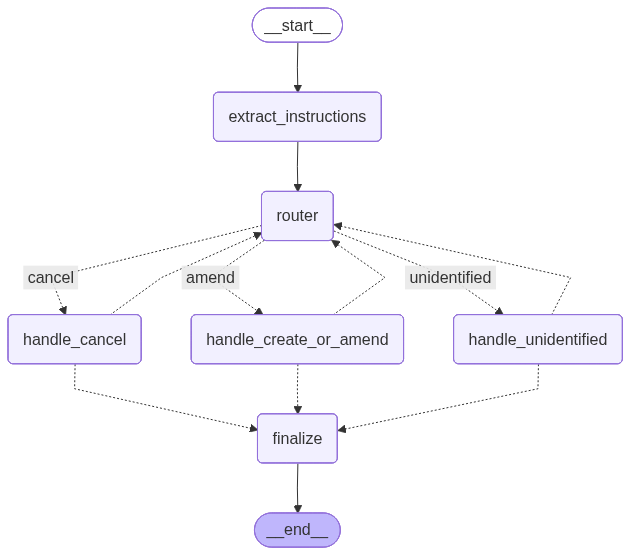

{
  "instructions": [
    {
      "type": "cancel",
      "clientRef": "XYZABC",
      "scRef": null,
      "isin": null,
      "qty": null,
      "settlementDate": null,
      "sfkAccount": null,
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    },
    {
      "type": "create",
      "clientRef": "QWERTY",
      "scRef": null,
      "isin": "DFGHISIN",
      "qty": "100",
      "settlementDate": null,
      "sfkAccount": "1234",
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    },
    {
      "type": "amend",
      "clientRef": "AMEND001",
      "scRef": null,
      "isin": null,
      "qty": null,
      "settlementDate": "5th July",
      "sfkAccount": null,
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    }
  ]
}


In [11]:

# ---------------------------------------------------------------------------
# 11. QUICK TEST
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    visualize_graph(graph)

    # This message deliberately contains THREE instructions, chosen to
    # exercise every branch in this graph:
    #   - a cancel with clientRef present -> should pass validation clean
    #   - a create with ALL required fields present -> should pass clean
    #   - an amend with only clientRef -> should ALSO pass clean, because
    #     amend's required-field list is just clientRef (per our rule above)
    sample_message = (
        "Please cancel the trade has client reference XYZABC, "
        "Also create a new trade with client reference QWERTY, "
        "it should have the ISIN DFGHISIN, Qty=100, SFK Account = 1234. "
        "Also amend trade with client reference AMEND001, change settlement date to 5th July."
    )

    final_state = graph.invoke({
        "raw_message": sample_message,
        "all_instructions": [],
        "current_index": 0,
        "processed_instructions": [],
        "result": None,
        "error": None,
    })

    # .model_dump() converts the Pydantic object back into a plain dict/JSON.
    print(json.dumps(final_state["result"].model_dump(), indent=2))


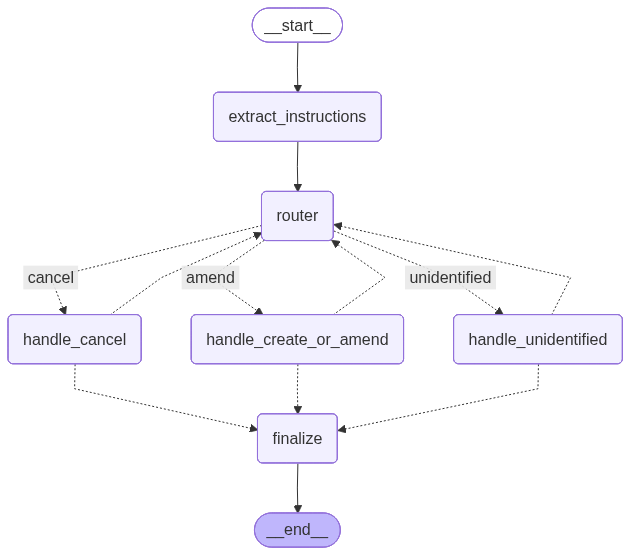

{
  "instructions": [
    {
      "type": "cancel",
      "clientRef": "XYZABC",
      "scRef": null,
      "isin": null,
      "qty": null,
      "settlementDate": null,
      "sfkAccount": null,
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    },
    {
      "type": "create",
      "clientRef": "QWERTY",
      "scRef": null,
      "isin": "DFGHISIN",
      "qty": "100",
      "settlementDate": null,
      "sfkAccount": null,
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": "Missing required fields: sfkAccount"
    },
    {
      "type": "amend",
      "clientRef": "AMEND001",
      "scRef": null,
      "isin": null,
      "qty": null,
      "settlementDate": "5th July",
      "sfkAccount": null,
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    }
  ]
}


In [24]:

# ---------------------------------------------------------------------------
# 11. QUICK TEST
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    visualize_graph(graph)

    # This message deliberately contains THREE instructions, chosen to
    # exercise every branch in this graph:
    #   - a cancel with clientRef present -> should pass validation clean
    #   - a create with ALL required fields present -> should pass clean
    #   - an amend with only clientRef -> should ALSO pass clean, because
    #     amend's required-field list is just clientRef (per our rule above)
    sample_message = (
        "Please cancel the trade has client reference XYZABC, "
        "Also create a new trade with client reference QWERTY, "
        "it should have the ISIN DFGHISIN, Qty=100 "
        "Also amend trade with client reference AMEND001, change settlement date to 5th July."
    )

    final_state = graph.invoke({
        "raw_message": sample_message,
        "all_instructions": [],
        "current_index": 0,
        "processed_instructions": [],
        "result": None,
        "error": None,
    })

    # .model_dump() converts the Pydantic object back into a plain dict/JSON.
    print(json.dumps(final_state["result"].model_dump(), indent=2))
